In [1]:
import pandas as pd
import seaborn as sns

In [2]:
wa=pd.read_csv("wannoreport.csv")
za=pd.read_csv("zeroreport.csv")

In [3]:
realscores={0:8.5,
 1:7,
 2:7,
 3:6,
 4:8.5,
 5:6,
 6:7}

In [4]:
wa['Actual']=wa['Unnamed: 0'].map(realscores)
wa['AbsError']=abs(wa['Actual']-wa['scores'])
za['Actual']=za['Unnamed: 0'].map(realscores)
za['AbsError']=abs(za['Actual']-za['scores'])

In [5]:
wa.groupby('Prompt')['AbsError'].median().sort_values()

Prompt
\nYou are a brutally     1.0
\nYou are an elite Ol    1.0
\nYou are a discus co    1.5
\nYou are an AI sport    1.5
\nYou are an expert A    4.0
Name: AbsError, dtype: float64

In [6]:
wa.groupby('Prompt')['AbsError'].mean().sort_values()

Prompt
\nYou are an elite Ol    0.875000
\nYou are a brutally     1.326923
\nYou are an AI sport    1.331683
\nYou are a discus co    1.990196
\nYou are an expert A    4.038835
Name: AbsError, dtype: float64

In [7]:
za.groupby(['model','Prompt',"Frames"])['AbsError'].median().sort_values()

model         Prompt                 Frames
qwen2.5vl:7b  \nYou are a discus co  12        0.5
                                     9         0.5
              \nYou are a brutally   12        0.5
              \nYou are an elite Ol  9         1.0
                                     3         1.0
                                              ... 
gemma3:12b    \nYou are a discus co  3         3.0
              \nYou are a brutally   15        3.0
qwen2.5vl:7b  \nYou are an expert A  15        3.0
llava:7b      \nYou are a discus co  6         5.0
                                     12        5.0
Name: AbsError, Length: 75, dtype: float64

In [8]:
wa.groupby(['Prompt',"model","Frames"])['AbsError'].median().sort_values()

Prompt                 model       Frames
\nYou are an elite Ol  llava:7b    15        0.0
                                   9         0.0
                                   12        0.0
                       gemma3:12b  9         0.5
                                   12        0.5
                                            ... 
\nYou are an expert A  llava:7b    12        5.0
                                   15        5.0
                                   6         5.0
                                   9         5.0
                                   3         6.0
Name: AbsError, Length: 75, dtype: float64

In [9]:
za.groupby(['Prompt',"model","Frames"])['AbsError'].mean().sort_values()

Prompt                 model         Frames
\nYou are an AI sport  llava:7b      3         0.714286
\nYou are an expert A  llava:7b      12        0.714286
\nYou are a brutally   qwen2.5vl:7b  12        0.714286
\nYou are an expert A  llava:7b      9         0.714286
\nYou are a discus co  qwen2.5vl:7b  6         0.714286
                                                 ...   
                       gemma3:12b    12        3.142857
\nYou are an expert A  qwen2.5vl:7b  15        3.285714
\nYou are a discus co  llava:7b      9         3.571429
                                     12        4.428571
                                     6         4.857143
Name: AbsError, Length: 75, dtype: float64

In [10]:
wa.groupby(['Prompt',"model","Frames"])['AbsError'].mean().sort_values()

Prompt                 model         Frames
\nYou are an elite Ol  gemma3:12b    12        0.428571
                       qwen2.5vl:7b  6         0.428571
                       llava:7b      9         0.571429
                       gemma3:12b    9         0.571429
                       llava:7b      12        0.571429
                                                 ...   
\nYou are an expert A  llava:7b      6         4.714286
                                     9         4.857143
                                     12        4.857143
                                     15        4.857143
                                     3         6.142857
Name: AbsError, Length: 75, dtype: float64

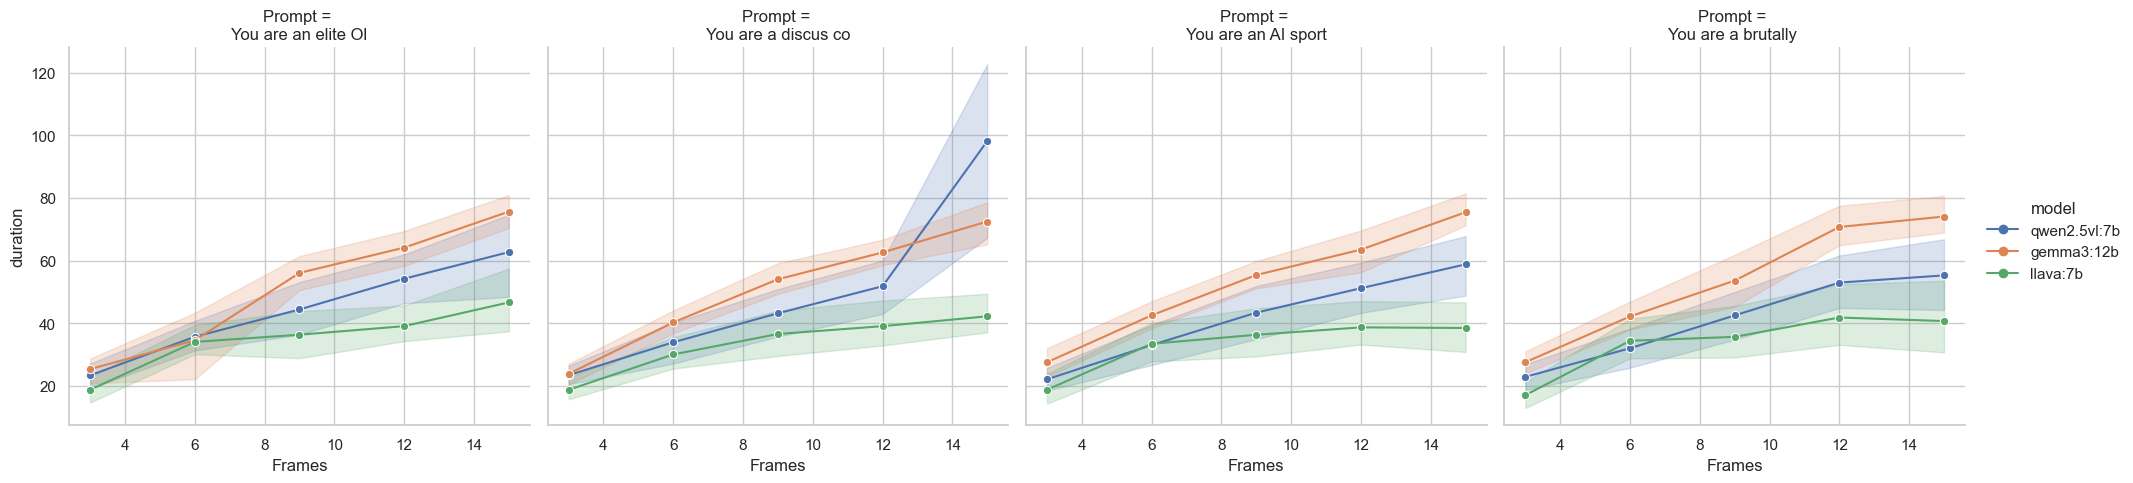

In [11]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="whitegrid", rc=custom_params)
sns.relplot(x='Frames',
            y='duration',
            hue='model',
            data=wa.query("Prompt!='\\nYou are an expert A'"),
            kind="line",
            col="Prompt",marker="o")

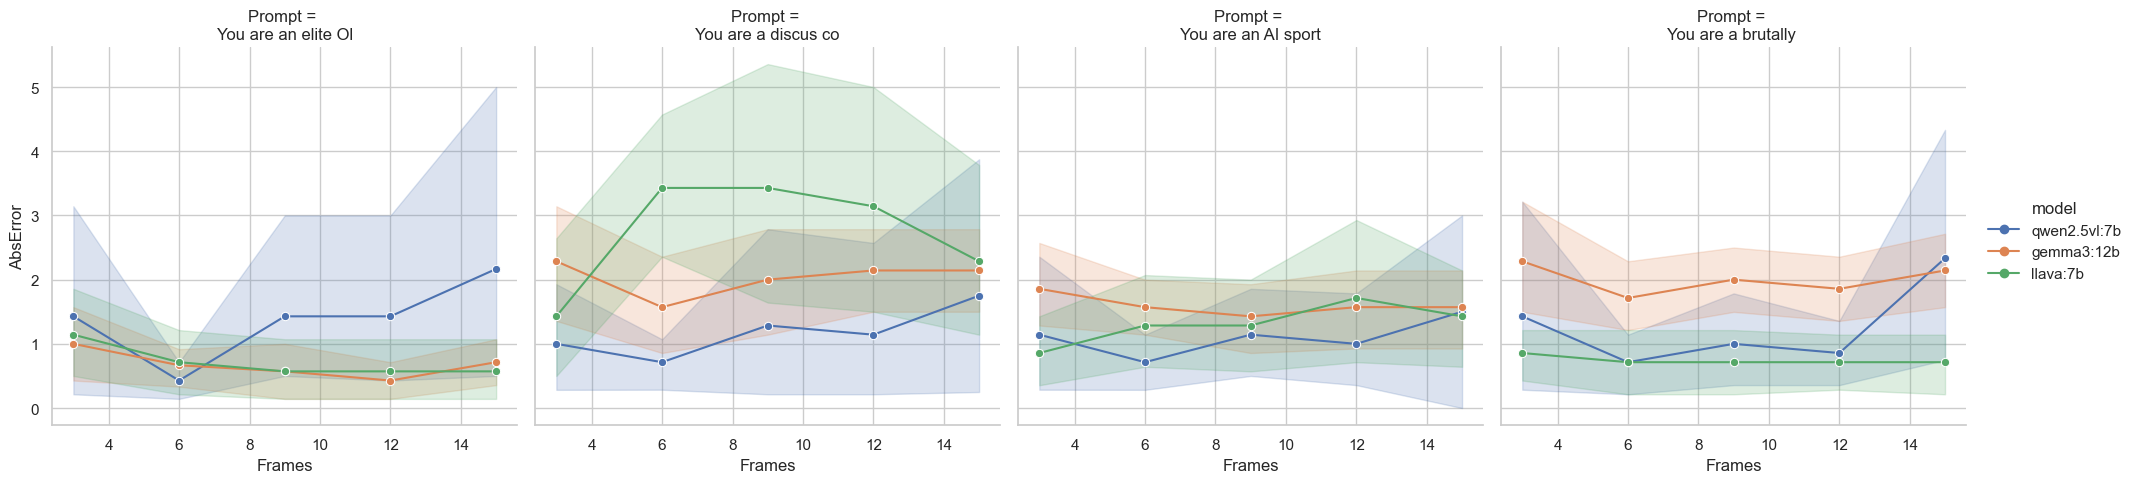

In [12]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="whitegrid", rc=custom_params)
sns.relplot(x='Frames',
            y='AbsError',
            hue='model',
            data=wa.query("Prompt!='\\nYou are an expert A'"),
            kind="line",
            col="Prompt",marker="o")